In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [2]:
day_data=pd.read_csv("/content/drive/MyDrive/data set/day.csv")
hour_data=pd.read_csv("/content/drive/MyDrive/data set/hour.csv")

In [3]:
day_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
hour_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
day_data.shape

(731, 16)

In [8]:
hour_data.shape

(17379, 17)

In [9]:
day_data['dteday'] = pd.to_datetime(day_data['dteday'])

In [10]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [11]:
hour_data['dteday'] = pd.to_datetime(hour_data['dteday'])

In [12]:
hour_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [13]:
day_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
726,False
727,False
728,False
729,False


In [14]:
day_data.duplicated().sum()

np.int64(0)

In [15]:
hour_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
17374,False
17375,False
17376,False
17377,False


In [16]:
hour_data.duplicated().sum()

np.int64(0)

In [17]:
day_data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [18]:
hour_data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [19]:
day_data.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [20]:
hour_data.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [21]:
day_data.shape

(731, 16)

In [22]:
day_data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)

In [23]:
day_data.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,4504.348837
std,1.110807,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,1937.211452
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,22.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,3152.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,4548.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,5956.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,8714.000000


In [24]:
day_data.shape

(731, 11)

In [25]:
hour_data.shape

(17379, 17)

In [26]:
hour_data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)

In [27]:
hour_data.describe()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


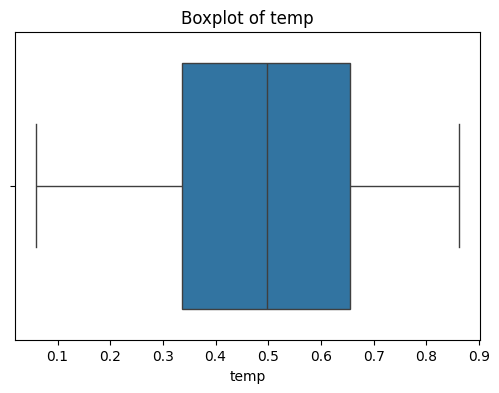

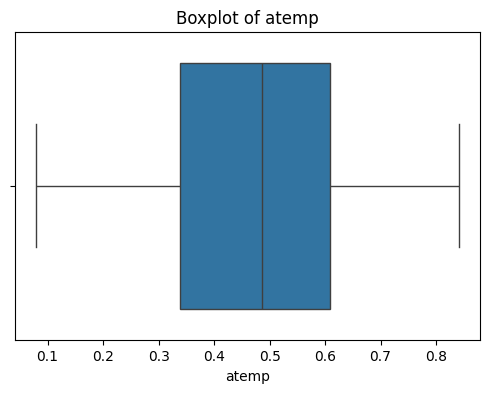

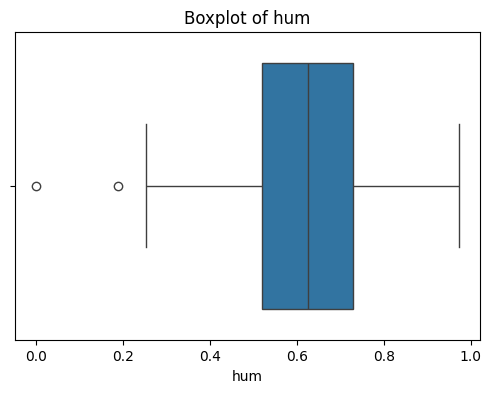

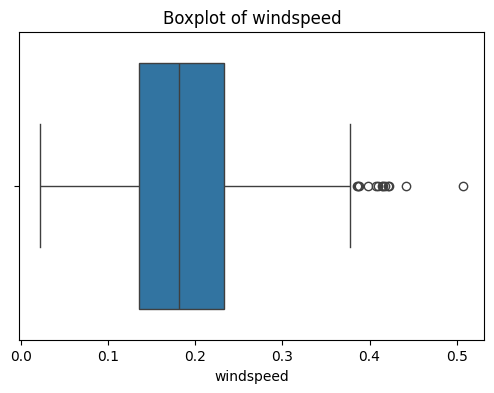

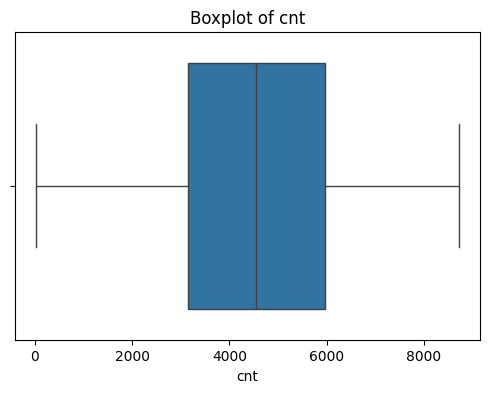

(731, 11)

In [28]:
column_name =["temp", "atemp", "hum", "windspeed", "cnt"]

for col in column_name:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=day_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
day_data.shape

In [29]:
num_cols = day_data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = day_data[col].quantile(0.25)
    Q3 = day_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    day_data = day_data[(day_data[col] >= lower) & (day_data[col] <= upper)]

print("After outlier removal:", day_data.shape)


After outlier removal: (696, 11)


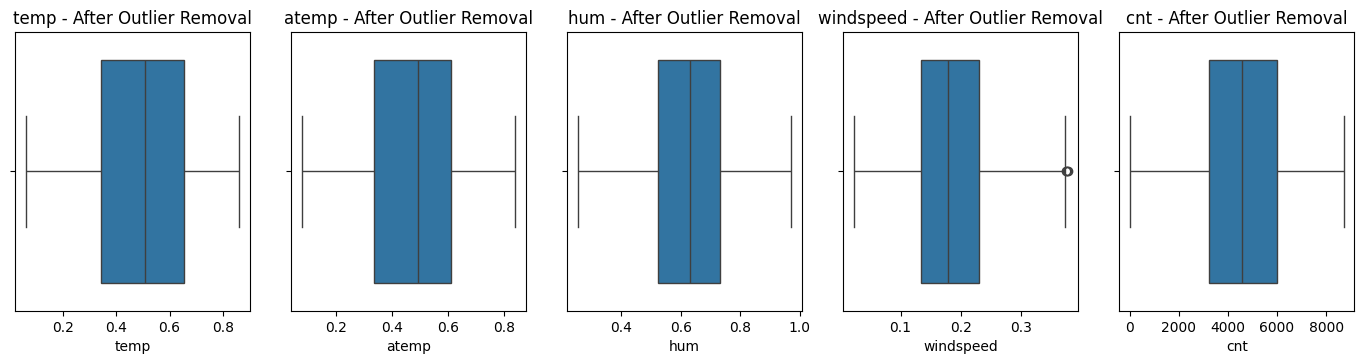

In [30]:
plt.figure(figsize=(14, 4))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(1,len(cols),i+1)
    sns.boxplot(x=day_data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)

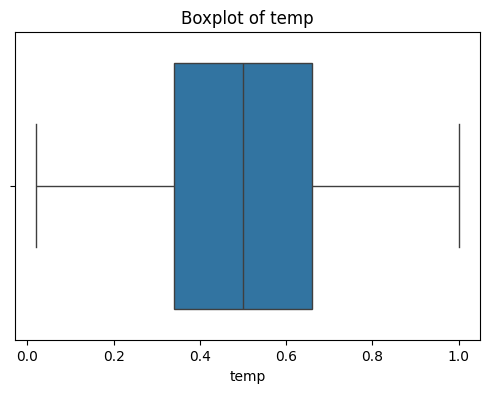

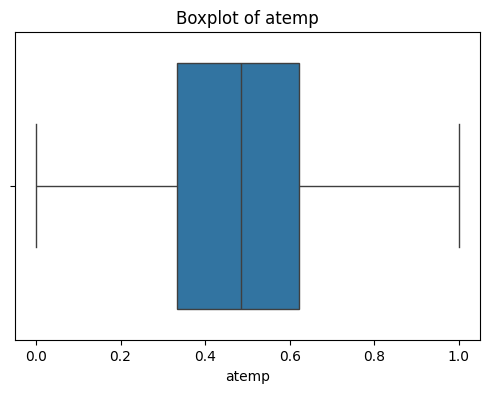

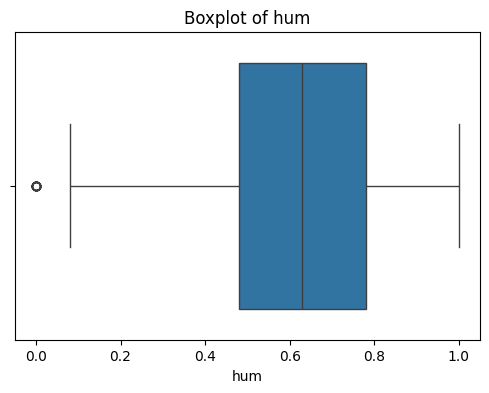

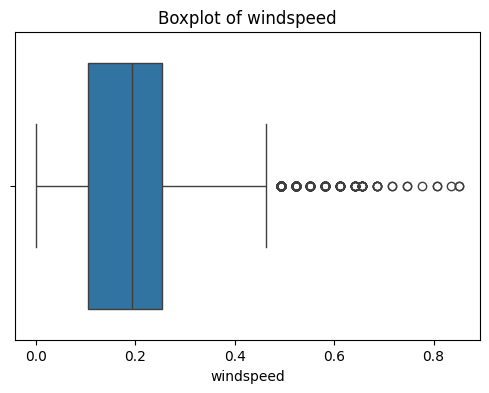

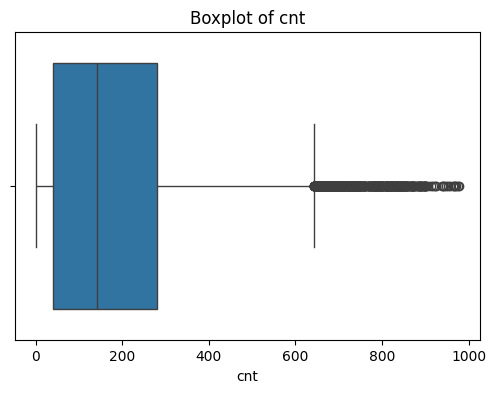

(17379, 12)

In [31]:
column_name =["temp", "atemp", "hum", "windspeed", "cnt"]

for col in column_name:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=hour_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
hour_data.shape

In [32]:
num_cols = hour_data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = hour_data[col].quantile(0.25)
    Q3 = hour_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    hour_data = hour_data[(hour_data[col] >= lower) & (hour_data[col] <= upper)]

print("After outlier removal:", hour_data.shape)

After outlier removal: (16042, 12)


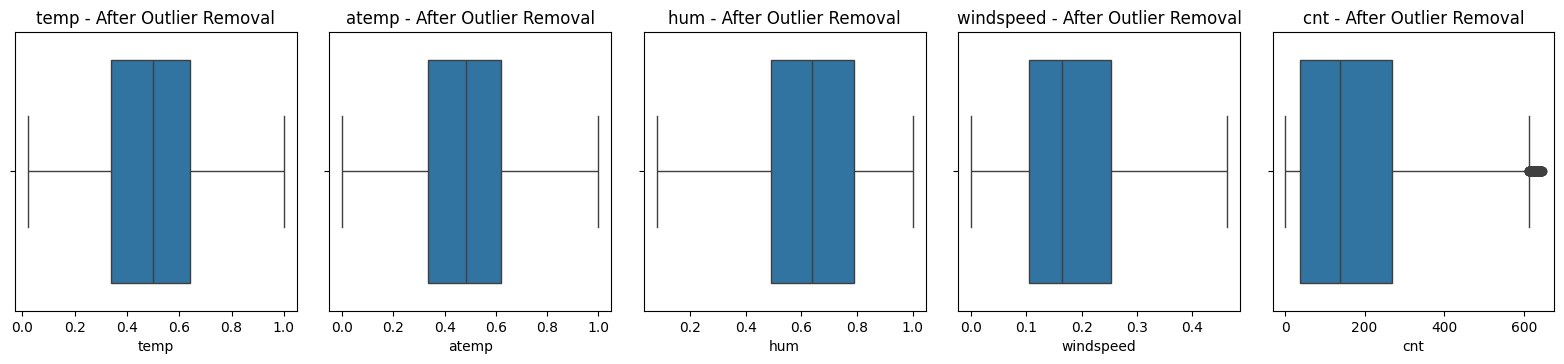

In [33]:
plt.figure(figsize=(16, 4))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(1,len(cols),i+1)
    sns.boxplot(x=hour_data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)

DAY DATA

In [34]:
X_day = day_data.drop(columns=['cnt'])
y_day = day_data['cnt']

X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)

rf_model_day = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model_day.fit(X_train_day, y_train_day)

y_pred_rf_day = rf_model_day.predict(X_test_day)

rf_r2_day = r2_score(y_test_day, y_pred_rf_day)
rf_mae_day = mean_absolute_error(y_test_day, y_pred_rf_day)
rf_rmse_day = np.sqrt(mean_squared_error(y_test_day, y_pred_rf_day))

print("\nRandom Forest Results (Day Data)")
print("R2 Score:", rf_r2_day)
print("MAE:", rf_mae_day)
print("RMSE:", rf_rmse_day)

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model_day = RandomForestRegressor(
   n_estimators=300,
    random_state=42
)


rf_model_day.fit(X_train_day, y_train_day)

y_pred_rf_day = rf_model_day.predict(X_test_day)

rf_r2_day = r2_score(y_test_day, y_pred_rf_day)
rf_mae_day = mean_absolute_error(y_test_day, y_pred_rf_day)
rf_rmse_day = np.sqrt(mean_squared_error(y_test_day, y_pred_rf_day))

print("\nRandom Forest Results (Day Data)")
print("R2 Score:", rf_r2_day)
print("MAE:", rf_mae_day)
print("RMSE:", rf_rmse_day)


Random Forest Results (Day Data)
R2 Score: 0.5648343804392585
MAE: 956.8288809523809
RMSE: 1174.9178565911516


In [36]:
rf_model_day = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model_day.fit(X_train_day, y_train_day)

# Predictions
y_train_pred_rf_day = rf_model_day.predict(X_train_day)
y_test_pred_rf_day = rf_model_day.predict(X_test_day)

# R2 scores
train_r2_rf_day = r2_score(y_train_day, y_train_pred_rf_day)
test_r2_rf_day = r2_score(y_test_day, y_test_pred_rf_day)

print("\nRandom Forest (Day Data)")
print("Train Accuracy (R2):", train_r2_rf_day)
print("Test Accuracy (R2):", test_r2_rf_day)


Random Forest (Day Data)
Train Accuracy (R2): 0.9491071991900369
Test Accuracy (R2): 0.5651041716969123


In [37]:
X_hour = hour_data.drop(columns=['cnt'])
y_hour = hour_data['cnt']

X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model_hour = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model_hour.fit(X_train_hour, y_train_hour)

y_pred_rf_hour = rf_model_hour.predict(X_test_hour)

rf_r2_hour = r2_score(y_test_hour, y_pred_rf_hour)
rf_mae_hour = mean_absolute_error(y_test_hour, y_pred_rf_hour)
rf_rmse_hour = np.sqrt(mean_squared_error(y_test_hour, y_pred_rf_hour))

print("\nRandom Forest (Hour Data)")
print("R2 Score:", rf_r2_hour)
print("MAE:", rf_mae_hour)
print("RMSE:", rf_rmse_hour)


Random Forest (Hour Data)
R2 Score: 0.864141359779376
MAE: 38.342108139557894
RMSE: 57.69374723671543


In [39]:
rf_model_hour = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model_hour.fit(X_train_hour, y_train_hour)
y_train_pred_rf_hour = rf_model_hour.predict(X_train_hour)
y_test_pred_rf_hour = rf_model_hour.predict(X_test_hour)
train_r2_rf_hour = r2_score(y_train_hour, y_train_pred_rf_hour)
test_r2_rf_hour = r2_score(y_test_hour, y_test_pred_rf_hour)

print("\nRandom Forest (Hour Data)")
print("Train Accuracy (R2):", train_r2_rf_hour)
print("Test Accuracy (R2):", test_r2_rf_hour)


Random Forest (Hour Data)
Train Accuracy (R2): 0.9813352139378063
Test Accuracy (R2): 0.864141359779376


In [40]:
DAY_NAMES = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

def predict_next_5_days(model, initial_input_series):
    predictions = []
    current_row = initial_input_series.copy()

    initial_day_name = DAY_NAMES[current_row["weekday"]]

    for _ in range(5):
        X_input = pd.DataFrame([current_row])
        pred = model.predict(X_input)[0]
        day_name = DAY_NAMES[current_row["weekday"]]
        predictions.append({"day_name": day_name, "prediction": int(pred)})
        current_row["weekday"] = (current_row["weekday"] + 1) % 7
        current_row["workingday"] = 0 if current_row["weekday"] in [0, 6] else 1
    return initial_day_name, predictions

def predict_next_5_hours(model, initial_input_series):
    predictions = []
    current_row = initial_input_series.copy()

    initial_hour = current_row["hr"]

    for _ in range(5):
        X_input = pd.DataFrame([current_row])
        pred = model.predict(X_input)[0]
        predictions.append({"hour": current_row["hr"], "prediction": int(pred)})
        current_row["hr"] = (current_row["hr"] + 1) % 24
        if current_row["hr"] == 0:
            current_row["weekday"] = (current_row["weekday"] + 1) % 7
            current_row["workingday"] = 0 if current_row["weekday"] in [0, 6] else 1
    return initial_hour, predictions

In [41]:
def get_day_input_from_user():
    """Prompts the user for daily features and returns them as a dictionary."""
    print("Enter DAY-wise input values (use dataset encoding):")
    SEASON_MAP = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
    WEEKDAY_MAP = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"}
    WEATHER_MAP = {1: "Clear / Few clouds", 2: "Mist / Cloudy", 3: "Light Rain / Snow", 4: "Heavy Rain / Thunderstorm"}
    MONTH_MAP = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}

    def get_validated_input(prompt, type_func, valid_range=None, value_map=None):
        while True:
            try:
                user_input = input(prompt)
                value = type_func(user_input)
                if valid_range and not (valid_range[0] <= value <= valid_range[1]):
                    print(f"Invalid input. Please enter a value between {valid_range[0]} and {valid_range[1]}.")
                elif value_map and value not in value_map:
                    print(f"Invalid input. Please choose from {list(value_map.keys())}.")
                else:
                    return value
            except ValueError:
                print("Invalid input. Please enter a valid number.")

    input_data = {}
    input_data["season"] = get_validated_input(f"Season ({', '.join([f'{k}:{v}' for k,v in SEASON_MAP.items()])}): ", int, (1, 4))
    input_data["mnth"] = get_validated_input(f"Month ({', '.join([f'{k}:{v}' for k,v in MONTH_MAP.items()])}): ", int, (1, 12))
    input_data["holiday"] = get_validated_input("Holiday (0:No, 1:Yes): ", int, (0, 1))
    input_data["weekday"] = get_validated_input(f"Weekday ({', '.join([f'{k}:{v}' for k,v in WEEKDAY_MAP.items()])}): ", int, (0, 6))
    input_data["workingday"] = get_validated_input("Working Day (0:No, 1:Yes): ", int, (0, 1))
    input_data["weathersit"] = get_validated_input(f"Weather ({', '.join([f'{k}:{v}' for k,v in WEATHER_MAP.items()])}): ", int, (1, 4))
    input_data["temp"] = get_validated_input("Temperature (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["atemp"] = get_validated_input("Feels-like Temperature (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["hum"] = get_validated_input("Humidity (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["windspeed"] = get_validated_input("Windspeed (0 to 100, normalized): ", float, (0.0, 100.0))

    return input_data

In [42]:
def get_hour_input_from_user():
    """Prompts the user for hourly features and returns them as a dictionary."""
    print("Enter HOUR-wise input values (use dataset encoding):")
    SEASON_MAP = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
    WEEKDAY_MAP = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"}
    WEATHER_MAP = {1: "Clear / Few clouds", 2: "Mist / Cloudy", 3: "Light Rain / Snow", 4: "Heavy Rain / Thunderstorm"}
    MONTH_MAP = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}


    def get_validated_input(prompt, type_func, valid_range=None, value_map=None):
        while True:
            try:
                user_input = input(prompt)
                value = type_func(user_input)
                if valid_range and not (valid_range[0] <= value <= valid_range[1]):
                    print(f"Invalid input. Please enter a value between {valid_range[0]} and {valid_range[1]}.")
                elif value_map and value not in value_map:
                    print(f"Invalid input. Please choose from {list(value_map.keys())}.")
                else:
                    return value
            except ValueError:
                print("Invalid input. Please enter a valid number.")

    input_data = {}
    input_data["season"] = get_validated_input(f"Season ({', '.join([f'{k}:{v}' for k,v in SEASON_MAP.items()])}): ", int, (1, 4))
    input_data["mnth"] = get_validated_input(f"Month ({', '.join([f'{k}:{v}' for k,v in MONTH_MAP.items()])}): ", int, (1, 12))
    input_data["hr"] = get_validated_input("Hour (0-23): ", int, (0, 23))
    input_data["holiday"] = get_validated_input("Holiday (0:No, 1:Yes): ", int, (0, 1))
    input_data["weekday"] = get_validated_input(f"Weekday ({', '.join([f'{k}:{v}' for k,v in WEEKDAY_MAP.items()])}): ", int, (0, 6))
    input_data["workingday"] = get_validated_input("Working Day (0:No, 1:Yes): ", int, (0, 1)) # This should ideally be derived from holiday and weekday
    input_data["weathersit"] = get_validated_input(f"Weather ({', '.join([f'{k}:{v}' for k,v in WEATHER_MAP.items()])}): ", int, (1, 4))
    input_data["temp"] = get_validated_input("Temperature (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["atemp"] = get_validated_input("Feels-like Temperature (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["hum"] = get_validated_input("Humidity (0 to 100, normalized): ", float, (0.0, 100.0))
    input_data["windspeed"] = get_validated_input("Windspeed (0 to 100, normalized): ", float, (0.0, 100.0))

    return input_data

In [43]:
print("--- Daily Bike Rental Prediction ---")
user_day_input = get_day_input_from_user()
input_day_series = pd.Series(user_day_input)

initial_day_name, day_predictions_output = predict_next_5_days(rf_model_day, input_day_series)

print(f"\nPrediction for the next 5 days starting from entered day ({initial_day_name}):")
for idx, day_pred in enumerate(day_predictions_output):
    print(f"Day {idx + 1} ({day_pred['day_name']}): Predicted bike count = {day_pred['prediction']}")

--- Daily Bike Rental Prediction ---
Enter DAY-wise input values (use dataset encoding):
Season (1:Spring, 2:Summer, 3:Fall, 4:Winter): 1
Month (1:January, 2:February, 3:March, 4:April, 5:May, 6:June, 7:July, 8:August, 9:September, 10:October, 11:November, 12:December): 1
Holiday (0:No, 1:Yes): 1
Weekday (0:Sunday, 1:Monday, 2:Tuesday, 3:Wednesday, 4:Thursday, 5:Friday, 6:Saturday): 1
Working Day (0:No, 1:Yes): 1
Weather (1:Clear / Few clouds, 2:Mist / Cloudy, 3:Light Rain / Snow, 4:Heavy Rain / Thunderstorm): 1
Temperature (0 to 100, normalized): 1
Feels-like Temperature (0 to 100, normalized): 1
Humidity (0 to 100, normalized): 1
Windspeed (0 to 100, normalized): 1

Prediction for the next 5 days starting from entered day (Monday):
Day 1 (Monday): Predicted bike count = 2468
Day 2 (Tuesday): Predicted bike count = 2420
Day 3 (Wednesday): Predicted bike count = 2413
Day 4 (Thursday): Predicted bike count = 2407
Day 5 (Friday): Predicted bike count = 2387


In [44]:

print("\n--- Hourly Bike Rental Prediction ---")
user_hour_input = get_hour_input_from_user()
input_hour_series = pd.Series(user_hour_input)

initial_hour, hour_predictions_output = predict_next_5_hours(rf_model_hour, input_hour_series)

print(f"\nPrediction for the next 5 hours starting from entered hour ({initial_hour}):")
for hour_pred in hour_predictions_output:
    print(f"Hour {hour_pred['hour']}: Predicted bike count = {hour_pred['prediction']}")


--- Hourly Bike Rental Prediction ---
Enter HOUR-wise input values (use dataset encoding):
Season (1:Spring, 2:Summer, 3:Fall, 4:Winter): 1
Month (1:January, 2:February, 3:March, 4:April, 5:May, 6:June, 7:July, 8:August, 9:September, 10:October, 11:November, 12:December): 1
Hour (0-23): 1
Holiday (0:No, 1:Yes): 1
Weekday (0:Sunday, 1:Monday, 2:Tuesday, 3:Wednesday, 4:Thursday, 5:Friday, 6:Saturday): 1
Working Day (0:No, 1:Yes): 1
Weather (1:Clear / Few clouds, 2:Mist / Cloudy, 3:Light Rain / Snow, 4:Heavy Rain / Thunderstorm): 1
Temperature (0 to 100, normalized): 1
Feels-like Temperature (0 to 100, normalized): 1
Humidity (0 to 100, normalized): 1
Windspeed (0 to 100, normalized): 1

Prediction for the next 5 hours starting from entered hour (1.0):
Hour 1.0: Predicted bike count = 20
Hour 2.0: Predicted bike count = 12
Hour 3.0: Predicted bike count = 7
Hour 4.0: Predicted bike count = 8
Hour 5.0: Predicted bike count = 18


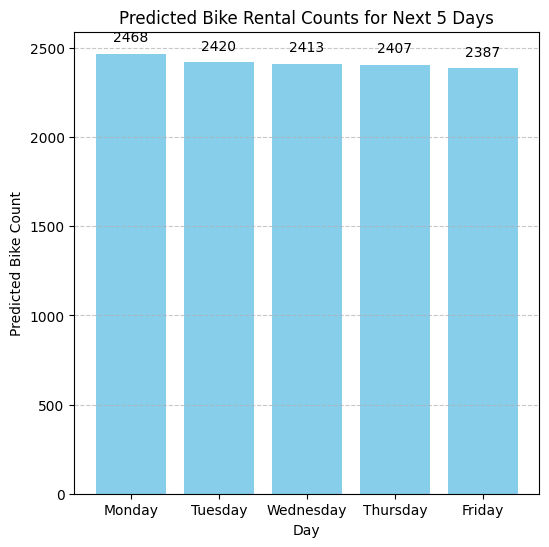

In [45]:
days = [day_pred['day_name'] for day_pred in day_predictions_output]
counts = [day_pred['prediction'] for day_pred in day_predictions_output]

plt.figure(figsize=(6, 6))
plt.bar(days, counts, color='skyblue')
plt.xlabel('Day')
plt.ylabel('Predicted Bike Count')
plt.title('Predicted Bike Rental Counts for Next 5 Days')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', va='bottom')

plt.show()

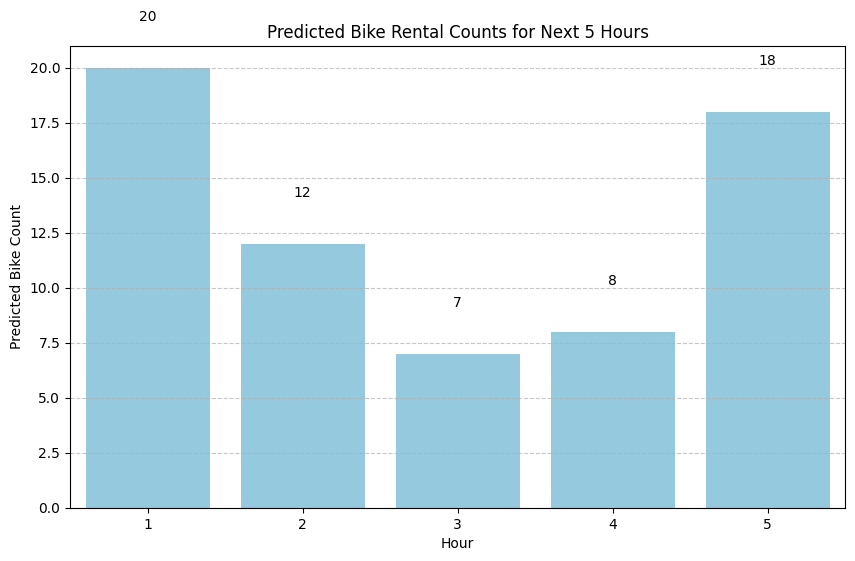

In [46]:
hours = [hour_pred['hour'] for hour_pred in hour_predictions_output]
counts_hour = [hour_pred['prediction'] for hour_pred in hour_predictions_output]

plt.figure(figsize=(10, 6))
sns.barplot(x=[str(int(h)) for h in hours], y=counts_hour, color='skyblue')
plt.xlabel('Hour')
plt.ylabel('Predicted Bike Count')
plt.title('Predicted Bike Rental Counts for Next 5 Hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, count in enumerate(counts_hour):
    plt.text(i, count + 2, str(count), ha='center', va='bottom') # Adjust +2 for better spacing

plt.show()